# 03 - Huấn Luyện Mô Hình

Notebook này huấn luyện bốn mô hình: Naive Forecast, Moving Average 24h, Random Forest và GRU. Dữ liệu đầu vào là file đã xử lý do thành viên 2 tạo ra.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from src.gru import GRURegressor, SequenceDataset, predict_gru, train_gru
from src.models import (
    build_random_forest,
    make_windows_for_indices,
    moving_average_forecast,
    naive_forecast,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1. Đọc dữ liệu processed

File cần có biến mục tiêu `cnt`, các đặc trưng đã xử lý và tốt nhất có cột `datetime`. Không sử dụng `casual` hoặc `registered` vì gây leakage.

In [2]:
processed_path = ROOT / 'data' / 'processed' / 'bike_sharing_processed.csv'
if not processed_path.exists():
    raise FileNotFoundError(
        f'Chưa có {processed_path}. Hãy chờ thành viên 2 tạo và merge dữ liệu processed.'
    )

df = pd.read_csv(processed_path)
print('Kích thước dữ liệu:', df.shape)
display(df.head())


Kích thước dữ liệu: (17211, 30)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,weekday_sin,weekday_cos,month_sin,month_cos,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,split
0,1,0,1,7,0,6,0,2,0.16,0.1818,...,-0.974928,-0.222521,0.5,0.866025,2.0,84.0,16.0,63.250000,55.796408,train
1,1,0,1,8,0,6,0,3,0.16,0.1818,...,-0.974928,-0.222521,0.5,0.866025,9.0,210.0,40.0,60.125000,56.677050,train
2,1,0,1,9,0,6,0,3,0.16,0.1818,...,-0.974928,-0.222521,0.5,0.866025,15.0,134.0,32.0,52.000000,47.490045,train
3,1,0,1,10,0,6,0,2,0.18,0.1970,...,-0.974928,-0.222521,0.5,0.866025,20.0,63.0,13.0,47.250000,44.541383,train
4,1,0,1,11,0,6,0,2,0.20,0.1818,...,-0.974928,-0.222521,0.5,0.866025,61.0,67.0,2.0,47.166667,44.512496,train


## 2. Xác định target, feature và chronological split

Nếu thành viên 2 đã tạo cột `split`, notebook sử dụng cột đó. Nếu chưa có, notebook chia 70/15/15 theo thứ tự thời gian.

In [3]:
TARGET = 'cnt'
if TARGET not in df.columns:
    raise ValueError(f'Dữ liệu phải có biến mục tiêu {TARGET!r}.')

if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime').reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

leakage_columns = {'casual', 'registered'}
present_leakage = leakage_columns.intersection(df.columns)
if present_leakage:
    print('Loại bỏ biến leakage:', sorted(present_leakage))

excluded = {TARGET, 'instant', 'datetime', 'dteday', 'split'} | leakage_columns
feature_columns = [
    column for column in df.select_dtypes(include=[np.number]).columns
    if column not in excluded
]
if not feature_columns:
    raise ValueError('Không tìm thấy feature số để huấn luyện mô hình.')

n_rows = len(df)
if 'split' in df.columns:
    split_values = df['split'].astype(str).str.lower()
    train_indices = np.flatnonzero(split_values.eq('train'))
    validation_indices = np.flatnonzero(split_values.isin(['validation', 'val']))
    test_indices = np.flatnonzero(split_values.eq('test'))
else:
    train_end = int(n_rows * 0.70)
    validation_end = int(n_rows * 0.85)
    train_indices = np.arange(0, train_end)
    validation_indices = np.arange(train_end, validation_end)
    test_indices = np.arange(validation_end, n_rows)

if min(len(train_indices), len(validation_indices), len(test_indices)) == 0:
    raise ValueError('Train/validation/test split đang bị rỗng.')

print('Số feature:', len(feature_columns))
print('Feature:', feature_columns)
print('Train/validation/test:', len(train_indices), len(validation_indices), len(test_indices))


Số feature: 27
Feature: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24']
Train/validation/test: 12047 2582 2582


## 3. Baseline: Naive và Moving Average

Hai baseline chỉ sử dụng giá trị `cnt` trong quá khứ. Hàm dự báo đã dịch dữ liệu một bước nên không dùng giá trị tương lai.

In [4]:
target_all = df[TARGET].to_numpy(dtype=float)
naive_all = naive_forecast(target_all, lag=1)
moving_average_all = moving_average_forecast(target_all, window=24)

test_predictions = pd.DataFrame({
    'row_index': test_indices,
    'y_true': target_all[test_indices],
    'Naive Forecast': naive_all[test_indices],
    'Moving Average': moving_average_all[test_indices],
})
if 'datetime' in df.columns:
    test_predictions.insert(0, 'datetime', df.loc[test_indices, 'datetime'].to_numpy())
else:
    test_predictions.insert(0, 'datetime', test_indices)

display(test_predictions.head())


,datetime,row_index,y_true,Naive Forecast,Moving Average
0,2012-09-13 18:00:00,14629,782.22,782.22,312.810000
1,2012-09-13 19:00:00,14630,674.00,782.22,312.810000
2,2012-09-13 20:00:00,14631,463.00,674.00,314.435000
3,2012-09-13 21:00:00,14632,317.00,463.00,314.143333
4,2012-09-13 22:00:00,14633,251.00,317.00,314.601667


## 4. Random Forest

Random Forest sử dụng feature engineering của thành viên 2. Các lag feature phải được tạo bằng `shift` để chỉ sử dụng quá khứ.

In [5]:
x_tabular = df[feature_columns].astype(float)
valid_rows = x_tabular.notna().all(axis=1) & df[TARGET].notna()
rf_train_indices = train_indices[valid_rows.iloc[train_indices].to_numpy()]
rf_test_indices = test_indices[valid_rows.iloc[test_indices].to_numpy()]

random_forest = build_random_forest(random_state=SEED, n_estimators=300)
random_forest.fit(x_tabular.iloc[rf_train_indices], target_all[rf_train_indices])
rf_predictions = random_forest.predict(x_tabular.iloc[rf_test_indices])

test_predictions['Random Forest'] = np.nan
rf_lookup = dict(zip(rf_test_indices, rf_predictions))
test_predictions['Random Forest'] = test_predictions['row_index'].map(rf_lookup)
print('Random Forest đã huấn luyện trên', len(rf_train_indices), 'dòng.')


Random Forest đã huấn luyện trên 12047 dòng.


## 5. GRU với input window 24 giờ

Scaler chỉ được fit trên tập train để tránh data leakage. GRU sử dụng các feature đa chiều và `cnt` trong quá khứ; target là `cnt` ở giờ tiếp theo.

In [6]:
LOOKBACK = 24
HORIZON = 1

x_raw = df[feature_columns].astype(float).to_numpy()
# Điền các NaN còn lại bằng median tính trên train.
train_medians = np.nanmedian(x_raw[train_indices], axis=0)
nan_rows, nan_columns = np.where(~np.isfinite(x_raw))
x_raw[nan_rows, nan_columns] = train_medians[nan_columns]

x_scaler = StandardScaler().fit(x_raw[train_indices])
y_scaler = StandardScaler().fit(target_all[train_indices].reshape(-1, 1))
x_scaled = x_scaler.transform(x_raw)
y_scaled = y_scaler.transform(target_all.reshape(-1, 1)).reshape(-1)

# Past cnt được thêm như một input channel; windowing đảm bảo không thấy target tương lai.
sequence_features = np.column_stack([x_scaled, y_scaled])
x_train, y_train, train_target_indices = make_windows_for_indices(
    sequence_features, y_scaled, train_indices, LOOKBACK, HORIZON
)
x_validation, y_validation, validation_target_indices = make_windows_for_indices(
    sequence_features, y_scaled, validation_indices, LOOKBACK, HORIZON
)
x_test, y_test, gru_test_indices = make_windows_for_indices(
    sequence_features, y_scaled, test_indices, LOOKBACK, HORIZON
)

train_loader = DataLoader(SequenceDataset(x_train, y_train), batch_size=64, shuffle=True)
validation_loader = DataLoader(SequenceDataset(x_validation, y_validation), batch_size=128, shuffle=False)
test_loader = DataLoader(SequenceDataset(x_test, y_test), batch_size=128, shuffle=False)

print('Window shapes:', x_train.shape, x_validation.shape, x_test.shape)


Window shapes: (12023, 24, 28) (2582, 24, 28) (2582, 24, 28)


In [7]:
gru_model = GRURegressor(
    input_size=x_train.shape[-1],
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
)
history = train_gru(
    gru_model,
    train_loader,
    validation_loader,
    epochs=40,
    learning_rate=1e-3,
    patience=7,
)
print('Best epoch:', history.best_epoch)


Best epoch: 13


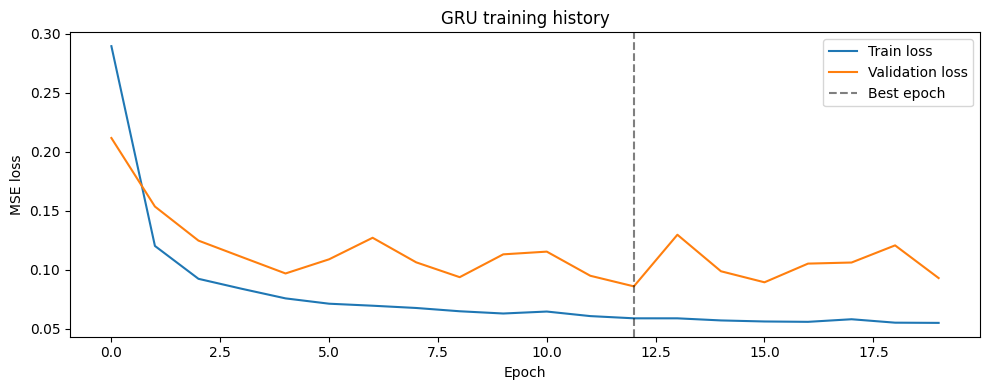

In [8]:
figures_dir = ROOT / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(10, 4))
plt.plot(history.train_loss, label='Train loss')
plt.plot(history.validation_loss, label='Validation loss')
plt.axvline(history.best_epoch - 1, color='black', linestyle='--', alpha=0.5, label='Best epoch')
plt.title('GRU training history')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / 'gru_training_curve.png', dpi=150)
plt.show()

gru_scaled_predictions = predict_gru(gru_model, test_loader)
gru_predictions = y_scaler.inverse_transform(gru_scaled_predictions.reshape(-1, 1)).reshape(-1)
gru_lookup = dict(zip(gru_test_indices, gru_predictions))
test_predictions['GRU'] = test_predictions['row_index'].map(gru_lookup)


## 6. Lưu dự báo

Notebook đánh giá sẽ đọc file này để đảm bảo mọi mô hình được so sánh trên cùng tập test.

In [9]:
results_dir = ROOT / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
predictions_path = results_dir / 'predictions.csv'
test_predictions.to_csv(predictions_path, index=False)
print('Đã lưu:', predictions_path)
display(test_predictions.head())


Đã lưu: C:\Users\Dell\Desktop\time series\time-series-group-06\results\predictions.csv


,datetime,row_index,y_true,Naive Forecast,Moving Average,Random Forest,GRU
0,2012-09-13 18:00:00,14629,782.22,782.22,312.810000,737.777267,731.981506
1,2012-09-13 19:00:00,14630,674.00,782.22,312.810000,600.572467,556.260742
2,2012-09-13 20:00:00,14631,463.00,674.00,314.435000,455.403333,440.753906
3,2012-09-13 21:00:00,14632,317.00,463.00,314.143333,350.343333,312.442291
4,2012-09-13 22:00:00,14633,251.00,317.00,314.601667,225.516667,230.951691
